# Sentiment Analysis

### Importing modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

import torch
import pytest
import re
from transformers import BertTokenizer, BertModel, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
import random

### Loading dataframes

In [2]:
df1 = pd.read_csv('./IMDB-Dataset.csv')

### Splitting into train sets and test sets

In [4]:
X = df1['review']
y = df1['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Converting `review` into numerical values using tf-idf

In [6]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## Logistic Regression

In [7]:
model1 = LogisticRegression(max_iter=1000)

model1.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [8]:
y_pred1 = model1.predict(X_test_tfidf)

In [9]:
print('Accuracy: ', accuracy_score(y_test, y_pred1))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred1))

Accuracy:  0.8889333333333334

Classification Report:

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      7411
    positive       0.88      0.90      0.89      7589

    accuracy                           0.89     15000
   macro avg       0.89      0.89      0.89     15000
weighted avg       0.89      0.89      0.89     15000



## L2 (Ridge) Regularization

In [10]:
model2 = LogisticRegression(solver='saga', penalty='l2', C=0.01)

model2.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


In [11]:
y_pred2 = model2.predict(X_test_tfidf)

In [12]:
print('Accuracy: ', accuracy_score(y_test, y_pred2))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred2))

Accuracy:  0.8294666666666667

Classification Report:

              precision    recall  f1-score   support

    negative       0.85      0.80      0.82      7411
    positive       0.81      0.86      0.84      7589

    accuracy                           0.83     15000
   macro avg       0.83      0.83      0.83     15000
weighted avg       0.83      0.83      0.83     15000



## L1 (Lasso) Regularization

In [13]:
model3 = LogisticRegression(solver='saga', penalty='l1', C=0.01)

model3.fit(X_train_tfidf, y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


In [14]:
y_pred3 = model3.predict(X_test_tfidf)

In [15]:
print('Accuracy: ', accuracy_score(y_test, y_pred3))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred3))

Accuracy:  0.6556666666666666

Classification Report:

              precision    recall  f1-score   support

    negative       0.79      0.41      0.54      7411
    positive       0.61      0.90      0.72      7589

    accuracy                           0.66     15000
   macro avg       0.70      0.65      0.63     15000
weighted avg       0.70      0.66      0.63     15000



## GridSearchCV

In [16]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000))
])

param_grid = {
    'tfidf__max_features': [3000, 5000, 10000],
    'tfidf__ngram_range': [(1,1),(1,2)],
    'tfidf__min_df': [1, 5],
    'tfidf__max_df': [0.8, 0.9],
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__penalty': ['l2']
}

grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)

Since GridSearchCV runs too slow, in case we put a large dataframe, we shall slice series `X_train`, `y_train`.

In [17]:
X_small = X_train[:10000]
y_small = y_train[:10000]

In [18]:
grid.fit(X_small, y_small)

Fitting 3 folds for each of 96 candidates, totalling 288 fits


,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'clf__C': [0.01, 0.1, ...], 'clf__penalty': ['l2'], 'tfidf__max_df': [0.8, 0.9], 'tfidf__max_features': [3000, 5000, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


## RandomizedSearchCV

#### RandomizedSearchCV is much faster than GridSearchCV.

In [19]:
random_search = RandomizedSearchCV(pipeline,param_distributions=param_grid, n_iter=10, cv=3, n_jobs=-1, verbose=2)

In [20]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"{'clf__C': [0.01, 0.1, ...], 'clf__penalty': ['l2'], 'tfidf__max_df': [0.8, 0.9], 'tfidf__max_features': [3000, 5000, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


## Testing our models

In [21]:
def predict_sentiment(text, model=None):
    if model == None:
        model = model1
    text_tfidf = vectorizer.transform([text])
    prediction = model.predict(text_tfidf)
    return prediction[0]

def predict_text(text, model=None):
    if model == None:
        model = grid
    return model.predict([text])[0]

In [22]:
print(predict_sentiment('This was a good film.'))
print(predict_sentiment('This was a horrible film.'))
print(predict_sentiment('The film was so good, that I had to turn it off.'))
print(predict_sentiment('The film was good, although there were some horrible scenes.'))
print(predict_sentiment('A bad ending, but I loved the film.'))
print(predict_sentiment('I was fascinated when he saved them, but I didn\'t like the film.'))

positive
negative
positive
negative
positive
negative


In [23]:
print(predict_sentiment('This was a good film.', model2))
print(predict_sentiment('This was a horrible film.', model2))
print(predict_sentiment('The film was so good, that I had to turn it off.', model2))
print(predict_sentiment('The film was good, although there were some horrible scenes.', model2))
print(predict_sentiment('A bad ending, but I loved the film.', model2))
print(predict_sentiment('I was fascinated when he saved them, but I didn\'t like the film.', model2))

positive
negative
positive
negative
negative
negative


In [24]:
print(predict_sentiment('This was a good film.', model3))
print(predict_sentiment('This was a horrible film.', model3))
print(predict_sentiment('The film was so good, that I had to turn it off.', model3))
print(predict_sentiment('The film was good, although there were some horrible scenes.', model3))
print(predict_sentiment('A bad ending, but I loved the film.', model3))
print(predict_sentiment('I was fascinated when he saved them, but I didn\'t like the film.', model3))

positive
positive
positive
positive
negative
positive


In [25]:
print(predict_text('This was a good film.'))
print(predict_text('This was a horrible film.'))
print(predict_text('The film was so good, that I had to turn it off.'))
print(predict_text('The film was good, although there were some horrible scenes.'))
print(predict_text('A bad ending, but I loved the film.'))
print(predict_text('I was fascinated when he saved them, but I didn\'t like the film.'))

positive
negative
positive
negative
positive
negative


In [26]:
print(predict_text('This was a good film.', random_search))
print(predict_text('This was a horrible film.', random_search))
print(predict_text('The film was so good, that I had to turn it off.', random_search))
print(predict_text('The film was good, although there were some horrible scenes.', random_search))
print(predict_text('A bad ending, but I loved the film.', random_search))
print(predict_text('I was fascinated when he saved them, but I didn\'t like the film.', random_search))

positive
negative
positive
negative
positive
negative


In [3]:
df1

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [4]:
df1.loc[df1["sentiment"] == "positive", "sentiment"] = 1
df1.loc[df1["sentiment"] == "negative", "sentiment"] = 0
df1 = df1.rename(columns={"review":"texts", "sentiment": "labels"})

In [5]:
df1

,texts,labels
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1
...,...,...
49995,I thought this movie did a down right good job...,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",0
49997,I am a Catholic taught in parochial elementary...,0
49998,I'm going to have to disagree with the previou...,0


In [6]:
print(df1.memory_usage().sum())

800132


In [7]:
df1['texts'] = df1['texts'].astype('str')
df1['labels'] = pd.to_numeric(df1['labels'], downcast='integer')

In [8]:
print(df1.memory_usage().sum())

450132


In [9]:
X = df1['texts']
y = df1['labels']
train_text, val_text, train_labels, val_labels = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

In [10]:
class CustomDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts.iloc[idx]
        label = self.labels.iloc[idx]

        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

In [11]:
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [12]:
batch_size = 32
max_len = 128

train_dataset = CustomDataset(train_text, train_labels, tokenizer, max_len)
val_dataset = CustomDataset(val_text, val_labels, tokenizer, max_len)

train_sampler = RandomSampler(train_dataset)
val_sampler = SequentialSampler(val_dataset)

train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler, num_workers=0, pin_memory=True)
# train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler, num_workers=4, pin_memory=True)
        
# scaler = torch.cuda.amp.GradScaler()

val_loader = DataLoader(val_dataset, batch_size=batch_size, sampler=val_sampler)

In [13]:
print(torch.xpu.is_available())

True


In [14]:
device = torch.device('xpu' if torch.xpu.is_available() else 'cpu')
print(device)
model.to(device)
model = torch.compile(model)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
loss_fn = torch.nn.CrossEntropyLoss()

xpu


In [ ]:
num_epochs = 3
best_accuracy = 0


for epoch in range(num_epochs):
    model.train()
    for batch in train_loader:
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

    model.eval()
    total_loss = 0
    predictions = []
    labels = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask =batch['attention_mask'].to(device)
            batch_labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, label=batch_labels)
            loss = outputs.loss
            if loss is not None:
                total_loss += loss.item()

            logits = outputs.logits
            batch_pred = torch.argmax(logits, dim=1)
            predictions.extend(batch_pred.cpu().numpy())
            labels.extend(batch_labels.cpu().numpy())

    epoch_loss = total_loss / len(val_loader)
    accuracy = accuracy_score(labels, predictions)
    print(f'Epoch {epoch+1}: Loss = {epoch_loss:.4f}, Accuracy = {accuracy:.4f}')

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save(model.state_dict(), 'best_model.pth')

C:\Users\MihajloTesic\AppData\Local\Temp\ipykernel_24948\1329687182.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\MihajloTesic\anaconda3\Lib\site-packages\torch\amp\autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


In [15]:
num_epochs = 3
best_accuracy = 0

for epoch in range(num_epochs):
    model.train()
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

    model.eval()
    total_loss = 0
    predictions = []
    labels = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask =batch['attention_mask'].to(device)
            batch_labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, label=batch_labels)
            loss = outputs.loss
            if loss is not None:
                total_loss += loss.item()

            logits = outputs.logits
            batch_pred = torch.argmax(logits, dim=1)
            predictions.extend(batch_pred.cpu().numpy())
            labels.extend(batch_labels.cpu().numpy())

    epoch_loss = total_loss / len(val_loader)
    accuracy = accuracy_score(labels, predictions)
    print(f'Epoch {epoch+1}: Loss = {epoch_loss:.4f}, Accuracy = {accuracy:.4f}')

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save(model.state_dict(), 'best_model.pth')

W0513 16:44:34.369000 22240 site-packages\torch\_inductor\utils.py:1250] [0/0] Not enough SMs to use max_autotune_gemm mode


InductorError: RuntimeError: Failed to find C compiler. Please specify via CC environment variable.

Set TORCHDYNAMO_VERBOSE=1 for the internal stack trace (please do this especially if you're reporting a bug to PyTorch). For even more developer context, set TORCH_LOGS="+dynamo"


### Now, let's do Sentiment Analysis, but for another dataframe!

In [2]:
df2 = pd.read_csv('C:/Users/MihajloTesic/Desktop/Python fajlovi/Ratings.csv')

Since this dataframe `df2` is too large, we would have to modify our columns, in case we want our code to run faster.

In [3]:
print(df2.memory_usage().sum())

27594852


In [4]:
df2['ISBN'] = df2['ISBN'].astype('str')
df2['User-ID'] = df2['User-ID'].astype('str')
df2['Book-Rating'] = pd.to_numeric(df2['Book-Rating'], downcast='integer')

In [5]:
print(df2.memory_usage().sum())

19546392


We're going to make a `dict` where the `key` is ISBN of the books in our dataframe `df2` and `value` is a list of tuples, where in each tuple there are two elements, where the first element is `User-ID` and the second element is `Book-Rating`.  We're also going to initialize `dict` for positive and negative ratings. 

In [6]:
# df2 = df2.sort_values(by='ISBN', ascending=True)
ISBN = df2['ISBN']
userID = df2['User-ID']
bookRating = df2['Book-Rating']
booksRatings = {}
positive_ratings = {}
negative_ratings = {}

for item in ISBN.unique():
    booksRatings[item] = []
    positive_ratings[item] = []
    negative_ratings[item] = []

for i in range(len(df2)):
    booksRatings[ISBN.loc[i]].append((str(userID.loc[i]), int(bookRating.loc[i])))

### A number of all ratings

In [7]:
cnt_all_ratings = 0
for key in booksRatings:
    cnt_all_ratings += len(booksRatings[key])

### Number of ratings per book

In [75]:
cnt_per_book = {}

for key in booksRatings:
    cnt_per_book[key] = len(booksRatings[key])

print(len(cnt_per_book))

340556


## Categorizing ratings

Now, we're going to categorize ratings. Let's assume that $x \in \{0, 1, 2,..., 10 \}$ is an arbitrary rating from our dataframe.
$x$ is a *positive rating of the book* if and only if $x>5$, otherwise, $x$ is a *negative rating of the book* (i.e. if and only if $x \leq 5$).

In [11]:
for key in booksRatings:
    for i in range(len(booksRatings[key])):
        if int(booksRatings[key][i][1]) > 5 and int(booksRatings[key][i][1]) <= 10:
            positive_ratings[key].append((str(booksRatings[key][i][0]), int(booksRatings[key][i][1])))
        elif int(booksRatings[key][i][1]) <= 5 and int(booksRatings[key][i][1]) >= 0:
            negative_ratings[key].append((str(booksRatings[key][i][0]), int(booksRatings[key][i][1])))

### Numbers of the positive ratings and the negative ratings

In [12]:
cnt_positive = 0
cnt_negative = 0
for key in positive_ratings:
    cnt_positive += len(positive_ratings[key])
for key in negative_ratings:
    cnt_negative += len(negative_ratings[key])

### Numbers of the positive ratings and the negative ratings per book

In [15]:
cnt_pos_per_book = {}
cnt_neg_per_book = {}

for key in positive_ratings:
    cnt_pos_per_book[key] = len(positive_ratings[key])
for key in negative_ratings:
    cnt_neg_per_book[key] = len(negative_ratings[key])

## Putting all dictionaries into dataframes

In [85]:
df_cnt_books_ratings = pd.DataFrame.from_dict(cnt_per_book, orient='index', columns=['Num-Ratings'])
df_cnt_pos_books_ratings = pd.DataFrame.from_dict(cnt_pos_per_book, orient='index', columns=['Num-Ratings'])
df_cnt_neg_books_ratings = pd.DataFrame.from_dict(cnt_neg_per_book, orient='index', columns=['Num-Ratings'])

### Descriptive statistics

In [38]:
print(df_cnt_books_ratings.describe())
print(f'Mode {df_cnt_books_ratings.mode()}')

         Num-Ratings
count  340556.000000
mean        3.376185
std        12.436252
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max      2502.000000
Mode    Num-Ratings
0            1


In [39]:
print(df_cnt_pos_books_ratings.describe())
print(f'Mode {df_cnt_pos_books_ratings.mode()}')

         Num-Ratings
count  340556.000000
mean        1.066691
std         4.535203
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max       663.000000
Mode    Num-Ratings
0            0


In [40]:
print(df_cnt_neg_books_ratings.describe())
print(f'Mode {df_cnt_neg_books_ratings.mode()}')

         Num-Ratings
count  340556.000000
mean        2.309494
std         8.465820
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max      2310.000000
Mode    Num-Ratings
0            1


# Sentiment Score

Let's assume that $P_i$ the number of positive ratings of the $i$-th book and $N_i$ the number of negative ratings of the $i$-th book, $i \in \{0, 1,...,K - 1\}$, where $K$ is the number of books (i.e. $K=340556$, in our case). Of course, it is true that $P_i \geq 0$ and $N_i \geq 0$ for all $i \in \{0, 1,..., K-1\}$.

Let's define numbers $S_i$ like this:
$$
S_i = 
\begin{cases}
\frac{P_i-N_i}{P_i+N_i}, \qquad P_i \neq 0, N_i \neq 0, i \in \{0, 1,..., K-1\}  \\
0, \qquad P_i=0, N_i=0, i \in \{0, 1,..., K-1\} 
\end{cases}
$$
We will call number $S_i$ a *Sentiment Score for the $i$-th book* or more shortly *Sentiment Score*.

Next, we can conclude for the sentiment score $S_i$ the following: $S_i \in [-1, 1]$.

Proof:

If $P_i = 0$ and $N_i = 0$ then $S_i = 0$ and $0 = S_i \in [-1, 1]$.

$P_i \neq 0, N_i \neq 0$:

1. $S_i \leq 1, i \in \{0, 1,..., K-1\}$

$$\frac{P_i-N_i}{P_i+N_i} \leq 1$$
$$P_i-N_i \leq P_i+N_i$$
$$-N_i \leq N_i$$
$$0 \leq 2N_i$$
$$0 \leq N_i$$
And this is true, since the number $N_i$ is non-negative (i.e. greater than or equal to zero).

2. $S_i \geq -1, i \in \{0, 1,..., K-1\}$

$$\frac{P_i-N_i}{P_i+N_i} \geq -1$$
$$P_i-N_i \geq -(P_i+N_i)$$
$$P_i-N_i \geq -P_i-N_i$$
$$P_i \geq -P_i$$
$$2P_i \geq 0$$
$$P_i \geq 0$$
This is also true (same conclusion as for $N_i$).

If $S_i = -1$, then *the $i$-th book has a completely negative rating*, or if $S_i = 1$, then *the $i$-th book has a completely positive rating*. Furthermore, *the $i$-th book is completely negative* or *the $i$-th book is completely positive* respectively.

### Why are we using this number?

With this number we can see how the users feel about some book. It shows a collective attitude of the users towards the book.

Now let's implement this in Python.

In [86]:
sentiment_score_per_book = {}
for key in cnt_per_book:
    p = cnt_pos_per_book[key]
    n = cnt_neg_per_book[key]
    s = 0
    if p != 0 and n != 0:
        s = (p-n)/(p+n)
    sentiment_score_per_book[key] = s

In [87]:
df_cnt_books_ratings.insert(1, 'Sentiment-score', list(sentiment_score_per_book.values()), True)

In [88]:
df_cnt_books_ratings

,Num-Ratings,Sentiment-score
034545104X,60,-0.466667
0155061224,2,0.000000
0446520802,116,-0.103448
052165615X,1,0.000000
0521795028,1,0.000000
...,...,...
1575660792,1,0.000000
0590907301,1,0.000000
0679752714,1,0.000000
0806917695,1,0.000000


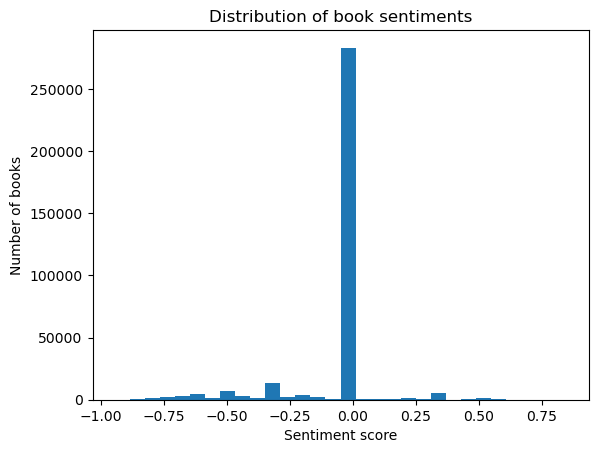

In [89]:
plt.hist(list(sentiment_score_per_book.values()), bins=30)
plt.xlabel('Sentiment score')
plt.ylabel('Number of books')
plt.title('Distribution of book sentiments')
plt.show()